In [2]:
import pandas as pd
from pathlib import Path

PAIR_CSV = Path(
    "/vol/biomedic3/tx1215/mamo-flow/assets/embed_splits_v1/"
    "EMBED_same_breast_CC_MLO_pairs.csv"
)

pairs_df = pd.read_csv(PAIR_CSV)

print("Shape:", pairs_df.shape)
print("\nColumns:")
print(pairs_df.columns.tolist())

print("\nPairs per split:")
print(pairs_df["split"].value_counts())

print("\nFirst rows:")
display(pairs_df.head())

Shape: (81581, 54)

Columns:
['split', 'empi_anon', 'acc_anon', 'laterality', 'cc_path', 'mlo_path', 'cc_cache_idx', 'mlo_cache_idx', 'cc_empi_anon', 'mlo_empi_anon', 'cc_tissueden', 'mlo_tissueden', 'cc_study_date_anon', 'mlo_study_date_anon', 'cc_acc_anon', 'mlo_acc_anon', 'cc_asses', 'mlo_asses', 'cc_age_at_study', 'mlo_age_at_study', 'cc_image_path', 'mlo_image_path', 'cc_FinalImageType', 'mlo_FinalImageType', 'cc_ImageLateralityFinal', 'mlo_ImageLateralityFinal', 'cc_ViewPosition', 'mlo_ViewPosition', 'cc_Manufacturer', 'mlo_Manufacturer', 'cc_ManufacturerModelName', 'mlo_ManufacturerModelName', 'cc_image_path_orig', 'mlo_image_path_orig', 'cc_shortpath', 'mlo_shortpath', 'cc_manufacturer_domain', 'mlo_manufacturer_domain', 'cc_density', 'mlo_density', 'cc_scanner', 'mlo_scanner', 'cc_view', 'mlo_view', 'cc_cview', 'mlo_cview', 'cc_age', 'mlo_age', 'cc_split', 'mlo_split', 'cc_ViewPosition_norm', 'mlo_ViewPosition_norm', 'cc_Laterality_norm', 'mlo_Laterality_norm']

Pairs per spli

,split,empi_anon,acc_anon,laterality,cc_path,mlo_path,cc_cache_idx,mlo_cache_idx,cc_empi_anon,mlo_empi_anon,...,cc_cview,mlo_cview,cc_age,mlo_age,cc_split,mlo_split,cc_ViewPosition_norm,mlo_ViewPosition_norm,cc_Laterality_norm,mlo_Laterality_norm
0,test,10000879,6992096043050201,L,/vol/biodata/data/Mammo/EMBED/pngs/1024x768/co...,/vol/biodata/data/Mammo/EMBED/pngs/1024x768/co...,14592,14590,10000879,10000879,...,0,0,41.879026,41.879026,test,test,CC,MLO,L,L
1,test,10000879,6992096043050201,R,/vol/biodata/data/Mammo/EMBED/pngs/1024x768/co...,/vol/biodata/data/Mammo/EMBED/pngs/1024x768/co...,14591,14589,10000879,10000879,...,0,0,41.879026,41.879026,test,test,CC,MLO,R,R
2,test,10015693,1334581155737139,L,/vol/biodata/data/Mammo/EMBED/pngs/1024x768/co...,/vol/biodata/data/Mammo/EMBED/pngs/1024x768/co...,8940,8939,10015693,10015693,...,0,0,65.167663,65.167663,test,test,CC,MLO,L,L
3,test,10015693,1334581155737139,R,/vol/biodata/data/Mammo/EMBED/pngs/1024x768/co...,/vol/biodata/data/Mammo/EMBED/pngs/1024x768/co...,8938,8937,10015693,10015693,...,0,0,65.167663,65.167663,test,test,CC,MLO,R,R
4,test,10015693,2281263876413228,L,/vol/biodata/data/Mammo/EMBED/pngs/1024x768/co...,/vol/biodata/data/Mammo/EMBED/pngs/1024x768/co...,14550,14549,10015693,10015693,...,0,0,67.407271,67.407271,test,test,CC,MLO,L,L


In [3]:
# --------------------------------------------------
# 1. CC / MLO view labels
# --------------------------------------------------

print("CC view values:")
print(pairs_df["cc_view"].value_counts(dropna=False))

print("\nMLO view values:")
print(pairs_df["mlo_view"].value_counts(dropna=False))


# --------------------------------------------------
# 2. Same patient / exam / breast
# --------------------------------------------------

same_patient = (
    pairs_df["cc_empi_anon"] == pairs_df["mlo_empi_anon"]
)

same_exam = (
    pairs_df["cc_acc_anon"] == pairs_df["mlo_acc_anon"]
)

same_breast = (
    pairs_df["cc_Laterality_norm"] == pairs_df["mlo_Laterality_norm"]
)

print("\nSame patient:")
print(same_patient.value_counts())

print("\nSame exam:")
print(same_exam.value_counts())

print("\nSame breast:")
print(same_breast.value_counts())


# --------------------------------------------------
# 3. Check encoded metadata
# --------------------------------------------------

for col in ["age", "view", "density", "scanner", "cview"]:
    print(f"\nCC {col}:")
    print(pairs_df[f"cc_{col}"].value_counts(dropna=False).sort_index())

    print(f"MLO {col}:")
    print(pairs_df[f"mlo_{col}"].value_counts(dropna=False).sort_index())


# --------------------------------------------------
# 4. CC/MLO should match for non-view attributes
# --------------------------------------------------

for col in ["age", "density", "scanner", "cview"]:
    same = pairs_df[f"cc_{col}"] == pairs_df[f"mlo_{col}"]

    print(f"\nSame {col}:")
    print(same.value_counts())


# --------------------------------------------------
# 5. View should be CC=1, MLO=0
# --------------------------------------------------

valid_view = (
    (pairs_df["cc_view"] == 1)
    &
    (pairs_df["mlo_view"] == 0)
)

print("\nCorrect CC/MLO encoded view:")
print(valid_view.value_counts())


# --------------------------------------------------
# 6. cache_idx sanity
# --------------------------------------------------

print("\nCC cache_idx missing:")
print(pairs_df["cc_cache_idx"].isna().sum())

print("MLO cache_idx missing:")
print(pairs_df["mlo_cache_idx"].isna().sum())

print("\nDuplicate CC cache indices within split:")
print(
    pairs_df.duplicated(
        subset=["split", "cc_cache_idx"]
    ).sum()
)

print("Duplicate MLO cache indices within split:")
print(
    pairs_df.duplicated(
        subset=["split", "mlo_cache_idx"]
    ).sum()
)

CC view values:
cc_view
1    81581
Name: count, dtype: int64

MLO view values:
mlo_view
0    81581
Name: count, dtype: int64

Same patient:
True    81581
Name: count, dtype: int64

Same exam:
True    81581
Name: count, dtype: int64

Same breast:
True    81581
Name: count, dtype: int64

CC age:
cc_age
20.244084      2
22.508334      2
24.096320      2
25.248978      1
25.383136      4
            ... 
88.935433      2
88.981978      2
88.992929      2
88.998405      2
89.000000    319
Name: count, Length: 16342, dtype: int64
MLO age:
mlo_age
20.244084      2
22.508334      2
24.096320      2
25.248978      1
25.383136      4
            ... 
88.935433      2
88.981978      2
88.992929      2
88.998405      2
89.000000    319
Name: count, Length: 16342, dtype: int64

CC view:
cc_view
1    81581
Name: count, dtype: int64
MLO view:
mlo_view
0    81581
Name: count, dtype: int64

CC density:
cc_density
0     6738
1    32797
2    36969
3     5077
Name: count, dtype: int64
MLO density:
mlo_den

In [4]:
assert (pairs_df["cc_view"] == 1).all()
assert (pairs_df["mlo_view"] == 0).all()

assert (
    pairs_df["cc_empi_anon"] == pairs_df["mlo_empi_anon"]
).all()

assert (
    pairs_df["cc_acc_anon"] == pairs_df["mlo_acc_anon"]
).all()

assert (
    pairs_df["cc_Laterality_norm"] == pairs_df["mlo_Laterality_norm"]
).all()

assert (
    pairs_df["cc_age"] == pairs_df["mlo_age"]
).all()

assert (
    pairs_df["cc_density"] == pairs_df["mlo_density"]
).all()

assert (
    pairs_df["cc_scanner"] == pairs_df["mlo_scanner"]
).all()

assert (
    pairs_df["cc_cview"] == pairs_df["mlo_cview"]
).all()

print("All pair checks passed.")

All pair checks passed.


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append("/vol/biomedic3/tx1215/mamo-flow")
from src.data_handle.embed import preprocess_breast


def show_pair(row):
    cc = preprocess_breast(row["cc_path"])
    mlo = preprocess_breast(row["mlo_path"])

    fig, axes = plt.subplots(1, 2, figsize=(9, 6))

    axes[0].imshow(cc, cmap="gray")
    axes[0].set_title(
        f"CC | {row['laterality']}\n"
        f"{row['split']} | patient {row['empi_anon']}"
    )
    axes[0].axis("off")

    axes[1].imshow(mlo, cmap="gray")
    axes[1].set_title(
        f"MLO | {row['laterality']}\n"
        f"{row['split']} | patient {row['empi_anon']}"
    )
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

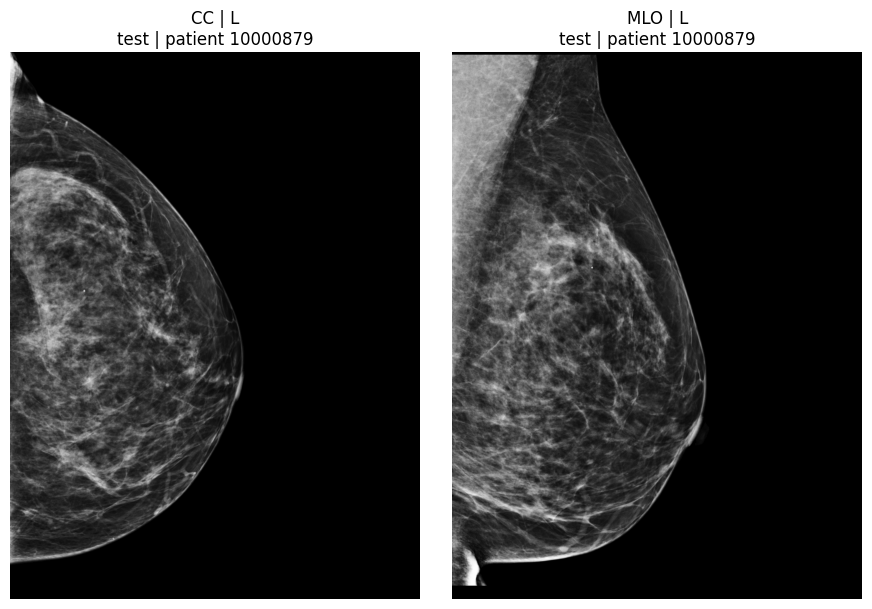

In [9]:
show_pair(pairs_df.iloc[0])